# 9주차_통계 기반 분석 방법론

- 주성분 분석(PCA)

---

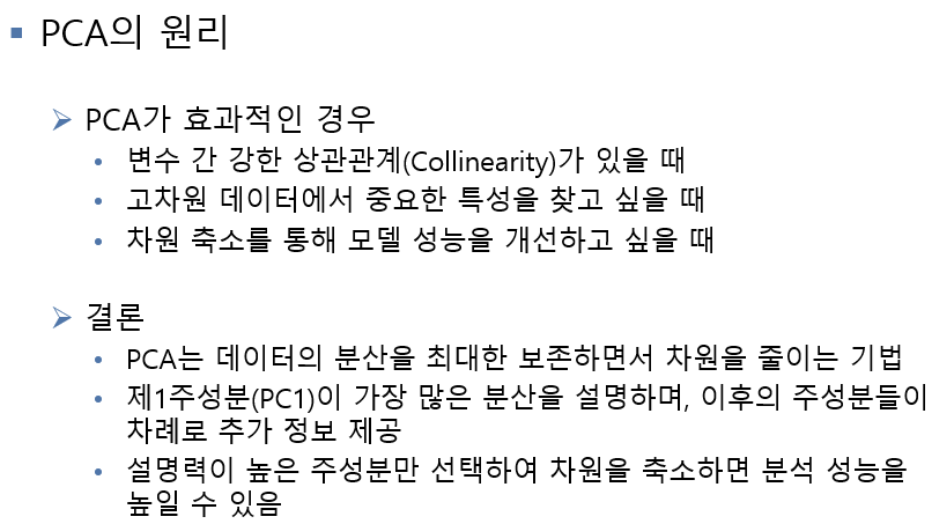

In [17]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Mac의 시스템 폰트 중 하나인 'AppleGothic'을 사용
plt.rcParams['font.family'] = 'AppleGothic'

# 마이너스(-) 기호가 깨지지 않도록 설정
mpl.rcParams['axes.unicode_minus'] = False


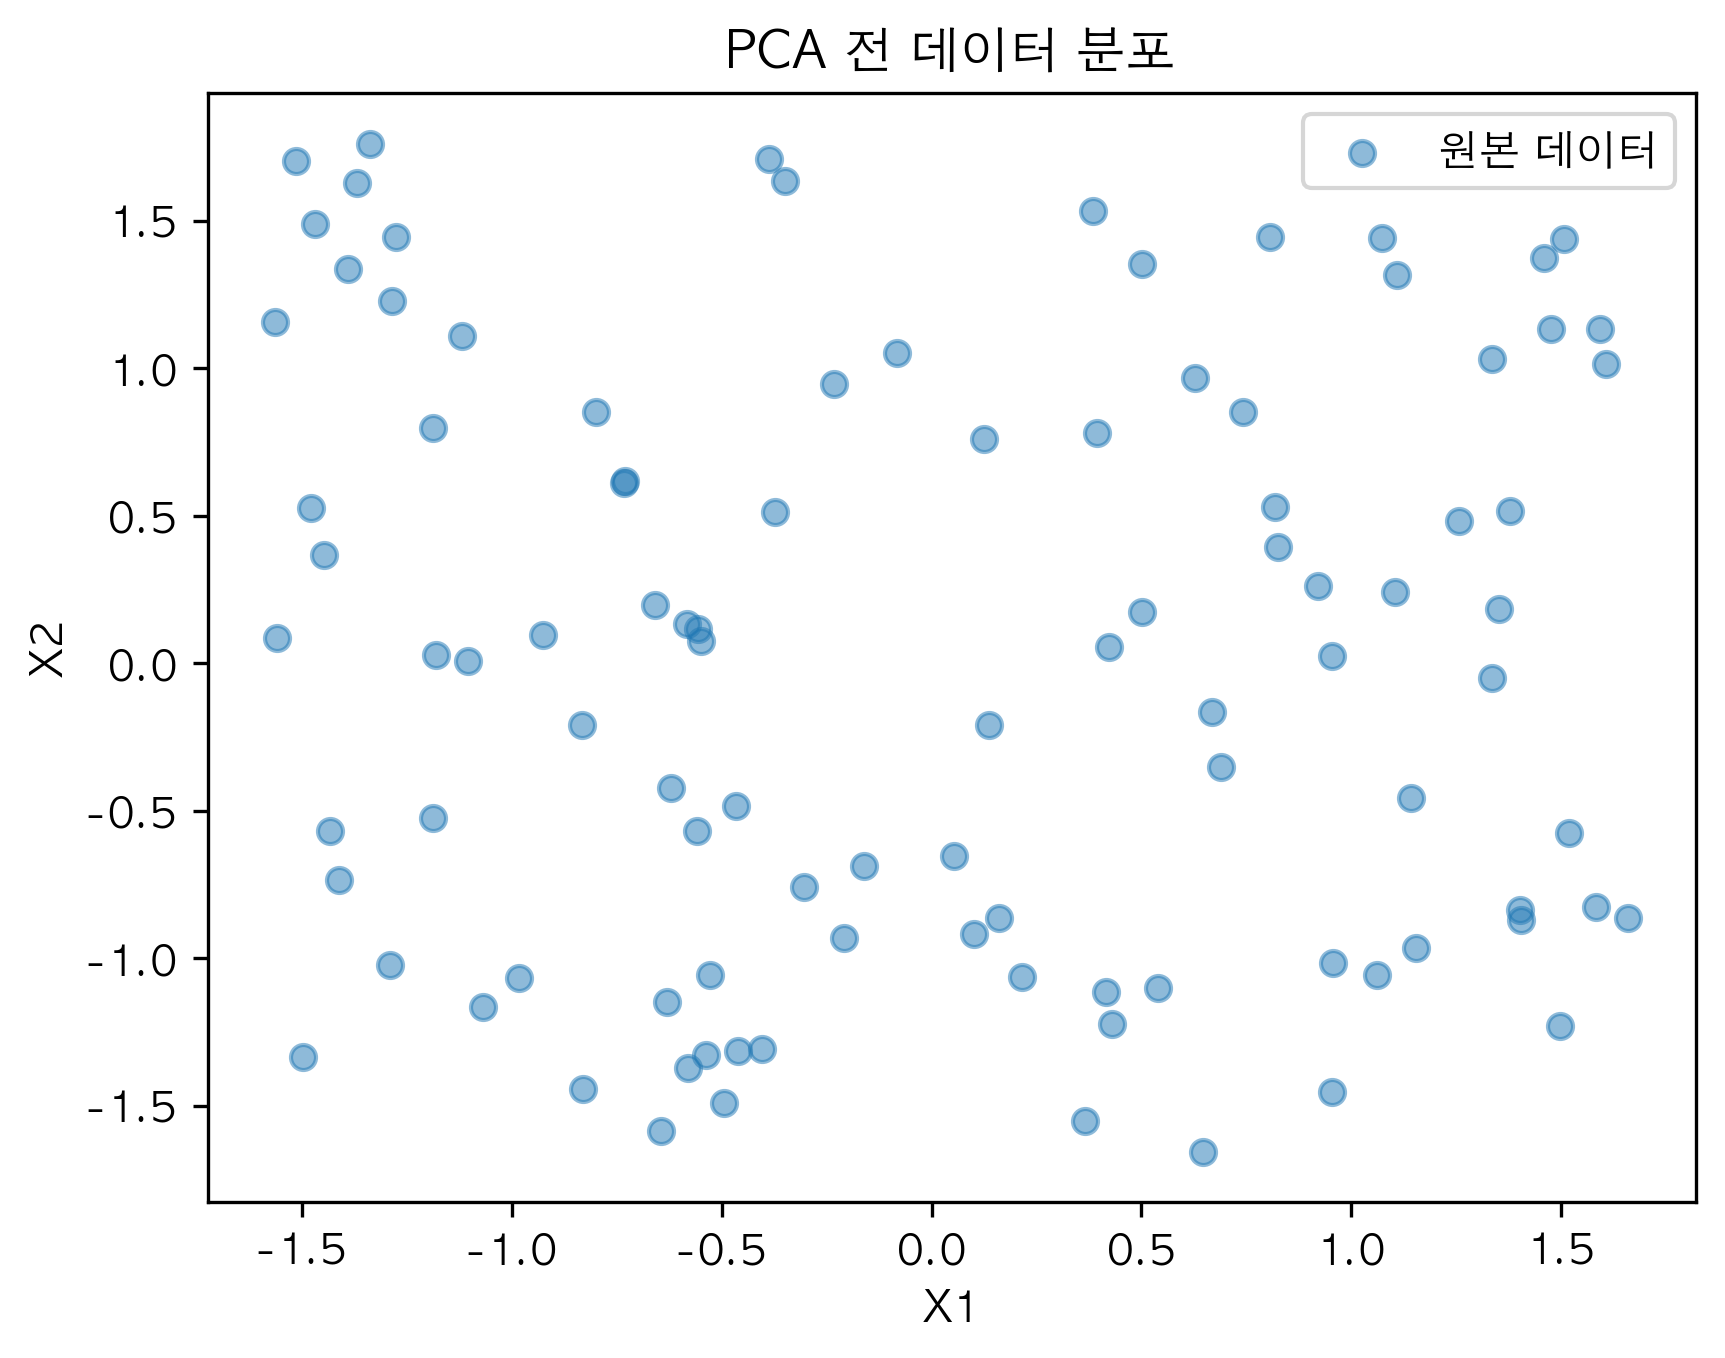

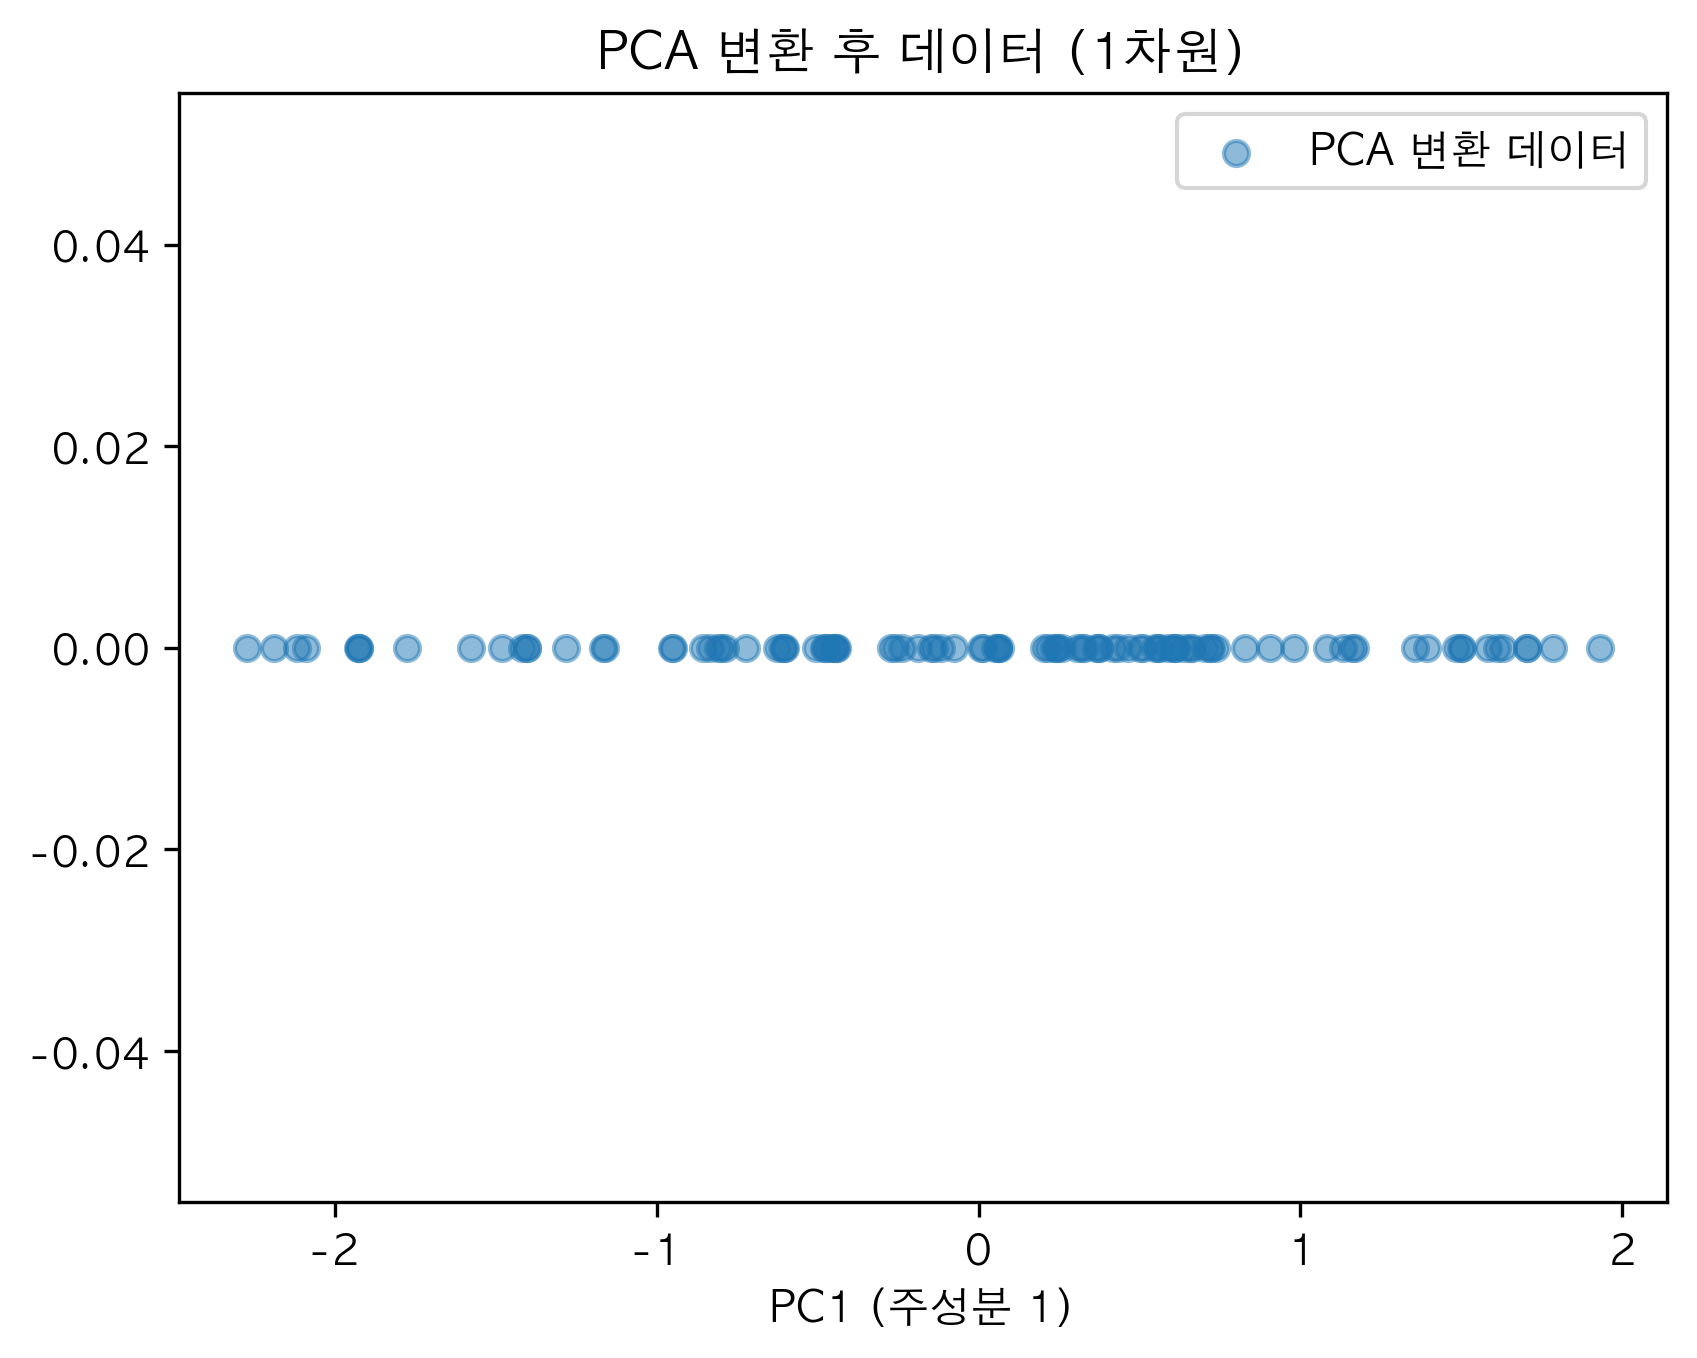

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 sklearn의 PCA(주성분 분석)를 이용하여 2차원 데이터를 1차원으로 축소하고,  
# 차원 축소 전후의 데이터를 matplotlib을 이용해 시각화하는 예제임.  
# 차원 축소 전 데이터는 2D 공간에 분포하며, PCA 적용 후에는 가장 큰 분산 방향으로 1D 선상에 투영됨.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 필요한 라이브러리 불러오기 (NumPy, matplotlib, scikit-learn)
# 2단계: 2차원 난수 샘플 데이터 생성
# 3단계: 데이터 표준화 (평균 0, 분산 1로 정규화)
# 4단계: PCA 적용 (1차원으로 축소)
# 5단계: 축소 전 데이터 산점도로 시각화
# 6단계: 축소 후 데이터 1차원 선상에 시각화
# ------------------------------------------------------------

import numpy as np
# 수치 계산, 배열 처리, 난수 생성 등을 위한 라이브러리 임포트
import matplotlib.pyplot as plt
# 데이터 시각화를 위한 matplotlib의 pyplot 모듈 임포트
from sklearn.decomposition import PCA
# 주성분 분석(PCA)을 수행하는 scikit-learn의 PCA 클래스 임포트
from sklearn.preprocessing import StandardScaler
# 평균 0, 분산 1로 데이터를 정규화하기 위한 전처리 도구 임포트

# ------------------------------------------------------------
# [2단계] 샘플 데이터 생성 (2차원 난수)
# ------------------------------------------------------------

np.random.seed(42)
# 무작위 수 생성 결과를 재현 가능하게 하기 위해 시드 고정

X = np.random.rand(100, 2) * 10
# 0~1 사이의 난수를 100개, 2차원 형태로 생성한 후 10을 곱해 범위를 0~10으로 확장
# 결과적으로 100개의 샘플과 2개의 특성을 가지는 (100, 2) 배열 생성

# ------------------------------------------------------------
# [3단계] 데이터 표준화 (평균 0, 분산 1 정규화)
# ------------------------------------------------------------

scaler = StandardScaler()
# 표준화를 위한 StandardScaler 객체 생성

X_scaled = scaler.fit_transform(X)
# 각 특성마다 평균을 0, 분산을 1로 정규화하여 새로운 데이터 배열 생성

# ------------------------------------------------------------
# [4단계] PCA 적용 (1차원으로 차원 축소)
# ------------------------------------------------------------

pca = PCA(n_components=1)
# 주성분의 개수를 1개로 지정하여 PCA 객체 생성

X_pca = pca.fit_transform(X_scaled)
# 정규화된 데이터를 PCA에 적용하여 주성분 1개 방향으로 투영된 1차원 데이터 생성

# ------------------------------------------------------------
# [5단계] 원본 데이터 시각화 (2D 산점도)
# ------------------------------------------------------------

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], label="원본 데이터", alpha=0.5)
# 표준화된 2차원 데이터를 산점도로 표현 (반투명 처리)

plt.xlabel("X1")
# x축 레이블 지정 (첫 번째 특성)

plt.ylabel("X2")
# y축 레이블 지정 (두 번째 특성)

plt.title("PCA 전 데이터 분포")
# 그래프 제목 설정

plt.legend()
# 범례 표시 설정

plt.show()
# 그래프 시각화 출력

# ------------------------------------------------------------
# [6단계] PCA 변환 후 데이터 시각화 (1D 투영)
# ------------------------------------------------------------

plt.scatter(X_pca, np.zeros_like(X_pca), label="PCA 변환 데이터", alpha=0.5)
# 주성분 축에 투영된 데이터(X_pca)를 x축에, y축은 0으로 고정하여 직선상에 표시

plt.xlabel("PC1 (주성분 1)")
# x축에 주성분 1(Principal Component 1) 명시

plt.title("PCA 변환 후 데이터 (1차원)")
# 그래프 제목 설정

plt.legend()
# 범례 표시 설정

plt.show()
# 그래프 시각화 출력


---

In [12]:
from sklearn.preprocessing import MinMaxScaler  
# 각 특성(feature)의 값을 0과 1 사이로 정규화하기 위한 도구의 임포트

from sklearn.decomposition import PCA  
# 데이터의 주요 정보를 보존하면서 차원을 축소하기 위한 주성분 분석 클래스의 임포트

import pandas as pd  
# 표 형식의 데이터를 처리하고 조작하기 위한 데이터프레임 기능 제공 라이브러리의 임포트

import numpy as np  
# 다차원 배열과 수치 연산을 지원하는 과학 계산용 라이브러리의 임포트

import seaborn as sns  
# 통계적 데이터 시각화를 위한 고수준 API 제공 라이브러리의 임포트

import matplotlib.pyplot as plt  
# 다양한 그래프 및 그림을 생성하기 위한 시각화 도구의 임포트

plt.rcParams['figure.dpi'] = 300  
# 모든 시각화 출력의 해상도를 300 DPI로 설정하여 고품질 이미지 생성을 유도

In [5]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/uciml/glass
df = pd.read_csv("../../../main/datasets/glass.csv")

# 데이터 샘플 확인
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [6]:
# 데이터 스케일 정규화

df1 = df.drop('Type', axis=1)  
# 전체 데이터에서 목표 변수인 'Type' 열을 제외한 독립 변수만 선택하는 명령문
# axis=1은 열 단위로 삭제함을 의미하며, PCA와 같은 비지도 학습에서 정답 레이블 제거가 필수임
# 결과적으로 df1은 정규화와 차원 축소 대상으로 사용할 입력 변수만 포함하는 DataFrame이 됨

MinMaxScaler = MinMaxScaler()  
# sklearn의 MinMaxScaler 클래스 객체를 생성하는 코드
# 각 특성(feature)의 최소값을 0, 최대값을 1로 맞추는 정규화(normalization) 기법을 적용하기 위한 전처리 도구의 생성 단계임
# 스케일링은 변수 간 단위 차이를 제거하고 모델의 학습 수렴 속도를 높이기 위해 필요함

df_minmax = MinMaxScaler.fit_transform(df1)  
# MinMaxScaler 객체에 df1 데이터를 전달하여 최소값 0, 최대값 1의 스케일로 모든 특성값을 선형적으로 변환함
# fit_transform()은 두 단계로 동작함:  
# (1) fit(): 각 특성의 최솟값과 최댓값을 계산하여 내부에 저장함  
# (2) transform(): 계산된 최솟값과 최댓값을 기준으로 각 값을 0~1 범위로 변환함
# 결과는 numpy 배열 형태로 반환되며, 원래의 DataFrame과는 별개의 객체임

df_minmax = pd.DataFrame(data=df_minmax, columns=df1.columns)  
# 정규화 결과로 생성된 numpy 배열을 다시 pandas의 DataFrame으로 변환함
# columns=df1.columns를 지정하여 정규화 전 데이터프레임의 원래 열 이름을 그대로 유지함
# 이는 후속 분석(예: 시각화, 변수 해석) 시 각 열의 의미를 보존하는 데 필요함

df_minmax.head()  
# 정규화된 df_minmax 데이터프레임의 상위 5개 행을 출력함
# 스케일링이 성공적으로 적용되었는지 확인하고, 값이 0~1 사이 범위에 있는지 검증하는 데 사용됨

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,0.432836,0.437594,1.000000,0.252336,0.351786,0.009662,0.308550,0.0,0.0
1,0.283582,0.475188,0.801782,0.333333,0.521429,0.077295,0.223048,0.0,0.0
2,0.220808,0.421053,0.790646,0.389408,0.567857,0.062802,0.218401,0.0,0.0
3,0.285777,0.372932,0.821826,0.311526,0.500000,0.091787,0.259294,0.0,0.0
4,0.275241,0.381955,0.806236,0.295950,0.583929,0.088567,0.245353,0.0,0.0


In [ ]:
# 주성분 개수 설정(최대 수 설정)
pca = PCA(n_components=9)  
# 주성분 분석(PCA, Principal Component Analysis)을 위한 객체 생성 명령문
# n_components=9는 전체 9개의 주성분을 생성하도록 지정함
# 입력 데이터가 9개의 독립 변수를 가지므로 가능한 최대 주성분 수는 9개이며, 이 설정은 모든 주성분을 계산하겠다는 의미를 가짐
# 주성분은 서로 직교하는 축으로서, 데이터의 분산을 가장 많이 설명하는 방향부터 순차적으로 정의됨

df_pca = pca.fit_transform(df_minmax)  
# 정규화된 데이터 df_minmax에 대해 주성분 분석을 적용하는 명령문
# fit(): 공분산 행렬을 기반으로 고유값 분해(Eigen decomposition)를 수행하여 주성분 축을 생성함  
# transform(): 각 데이터를 새로운 주성분 축으로 투영하여 저차원 표현으로 변환함  
# 결과는 입력 데이터를 9개의 주성분으로 표현한 numpy 배열이며, 정보 손실이 최소화된 상태로 차원 축소가 이루어짐

# 주성분으로 변형된 테이블 생성
df_pca = pd.DataFrame(data=df_pca, columns = ['C1','C2','C3','C4','C5','C6','C7','C8','C9'])  
# PCA 결과 배열을 pandas의 DataFrame으로 변환하는 명령문
# 각 주성분 축에 대해 'C1', 'C2', ..., 'C9'라는 열 이름을 부여하여 직관적 이해와 시각화를 용이하게 함
# 이 테이블은 원래 특성 공간 대신 주성분 공간에서 데이터를 표현하는 구조를 가짐

# 주성분 설명력 확인
np.round(pca.explained_variance_ratio_,3)  
# 각 주성분이 전체 데이터 분산에서 차지하는 비율(설명 분산 비율)을 소수점 셋째 자리까지 반올림하여 출력하는 명령문
# 설명력은 해당 주성분이 얼마나 많은 원래 데이터의 정보(분산)를 보존하고 있는지를 나타냄
# 출력값의 합이 1에 가까울수록 원 데이터의 정보 손실이 적고, 주성분 축이 데이터를 잘 표현하고 있음을 의미함


array([0.454, 0.18 , 0.126, 0.098, 0.069, 0.042, 0.026, 0.004, 0.   ])

In [8]:
# 주성분 개수 설정(2개 설정)
pca = PCA(n_components=2)  
# 주성분 분석(PCA)을 위한 PCA 클래스 객체의 생성 명령문
# n_components=2는 전체 입력 변수 중 가장 많은 정보를 담고 있는 2개의 주성분만 계산하도록 설정함
# 차원 축소 목적에서 사용되며, 고차원 데이터의 구조를 2차원 평면에서 시각화하기 위해 최소 주성분 수를 지정함
# 각 주성분은 기존 변수들의 선형 결합이며, 서로 직교하고 가장 큰 분산을 가진 방향을 기준으로 정의됨

df_pca = pca.fit_transform(df_minmax)  
# 정규화된 입력 데이터(df_minmax)에 대해 주성분 분석(PCA)을 수행하여 2차원으로 변환하는 명령문
# fit(): 입력 데이터의 공분산 행렬을 바탕으로 고유벡터와 고유값을 계산하여 주성분 축을 정의함
# transform(): 정의된 주성분 축에 따라 데이터를 투영함으로써 고차원 데이터를 2차원 주성분 공간으로 변환함
# 반환값은 N x 2 형태의 numpy 배열이며, 각 행은 변환된 두 개의 주성분 좌표로 구성됨

# 주성분으로 변형된 테이블 생성
df_pca = pd.DataFrame(data=df_pca, columns = ['C1','C2'])  
# 2개의 주성분(C1, C2)으로 구성된 결과 배열을 pandas의 DataFrame으로 변환하는 명령문
# 열 이름을 'C1', 'C2'로 명시하여 시각화 및 분석 시 주성분 간 구분을 명확하게 함
# 이 테이블은 이제 원래의 다변량 데이터가 아니라, 축소된 2차원 표현을 담은 저차원 표현 테이블임

df_pca.head()  
# 주성분으로 변형된 df_pca 테이블의 상위 5개 행을 출력하는 명령문
# 데이터가 정상적으로 2차원으로 투영되었는지, 값의 범위가 이상하지 않은지를 시각적으로 검토하기 위한 확인 단계임


,C1,C2
0,0.402106,0.032707
1,0.206320,-0.144705
2,0.188617,-0.194854
3,0.237208,-0.097064
4,0.223972,-0.121779


<Axes: xlabel='C1', ylabel='C2'>

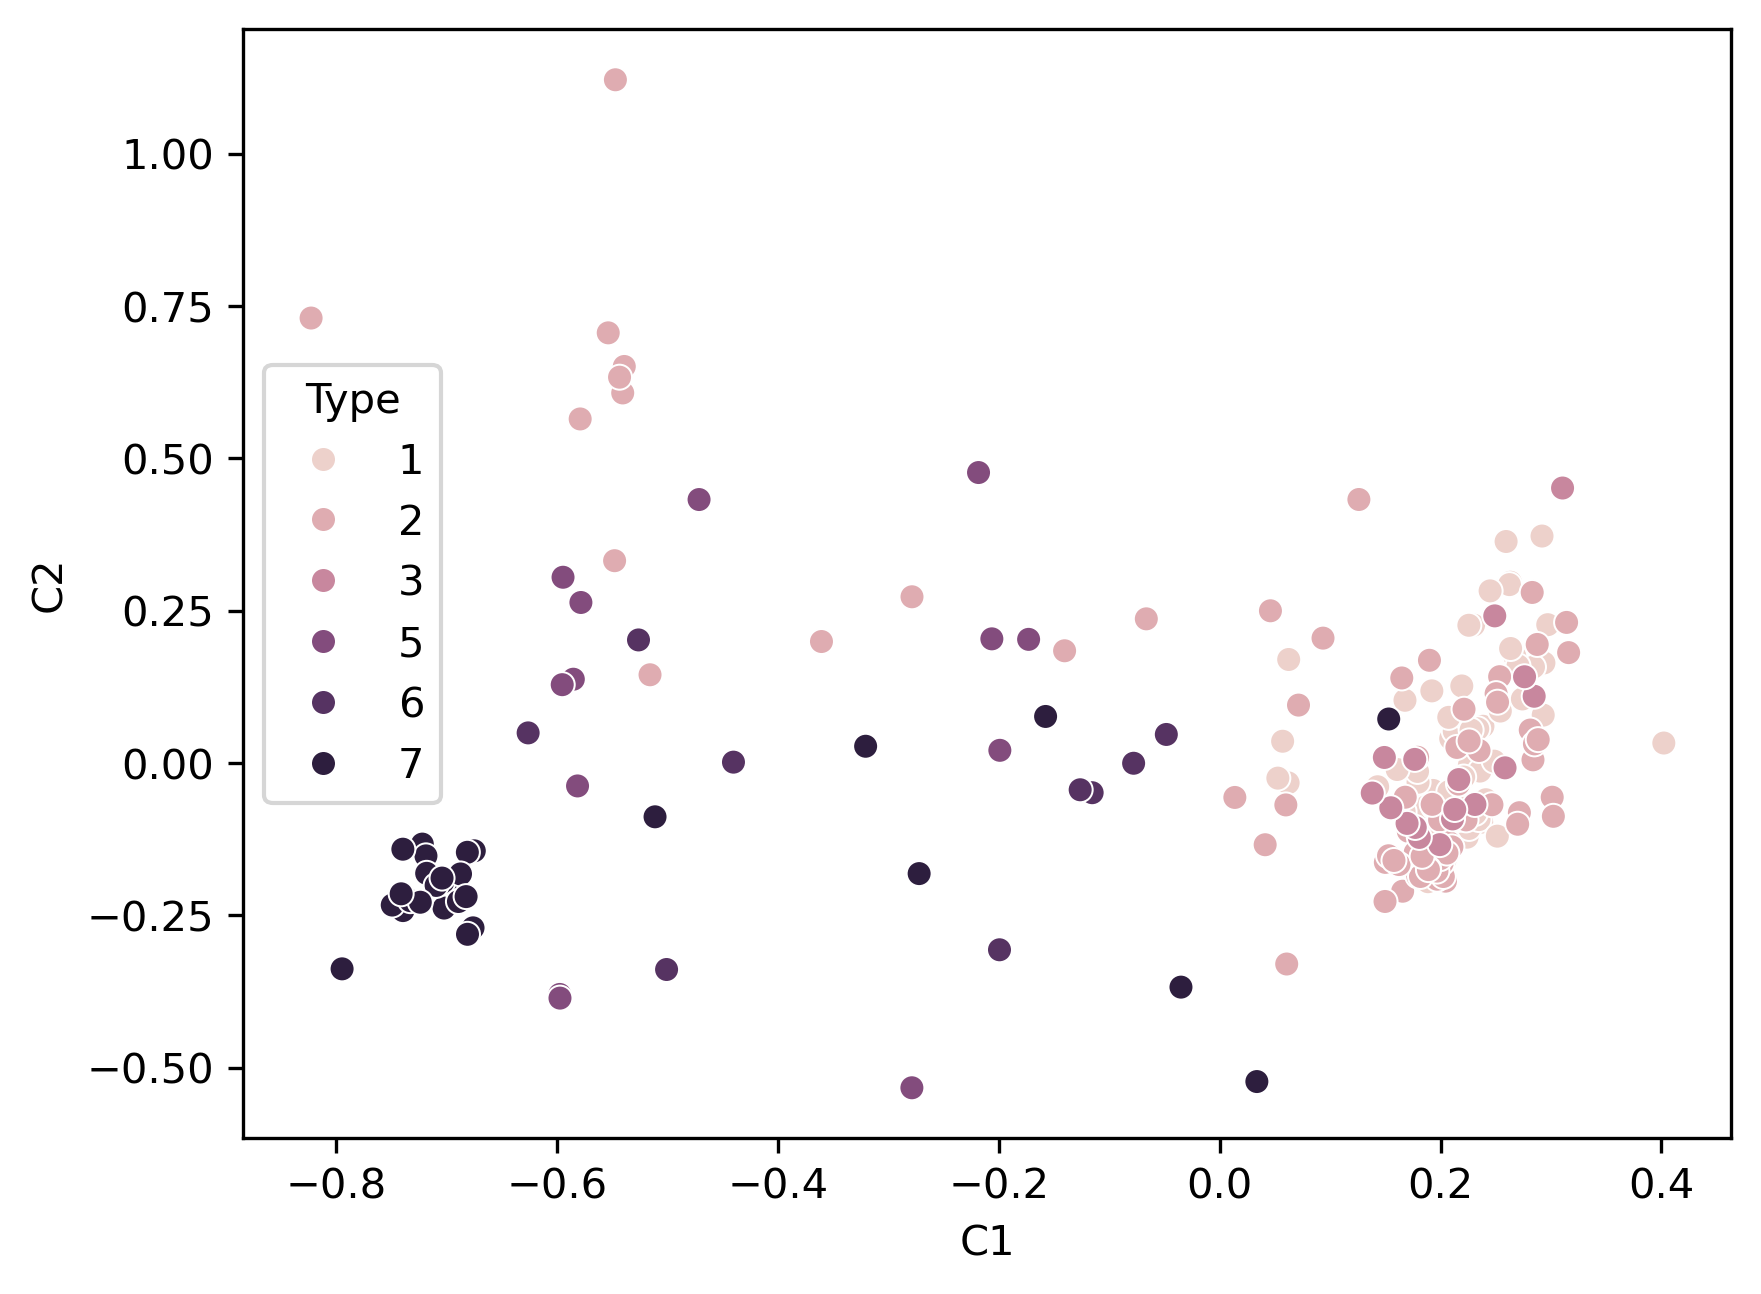

In [9]:
# 주성분에 따른 종속변수 시각화

# 주성분 테이블에 종속변수 칼럼 결합
df_concat = pd.concat([df_pca, df[['Type']]], axis=1)  
# 2차원 주성분 분석 결과(df_pca)와 원본 데이터의 종속변수 'Type' 열을 수평 방향으로 병합하는 명령문
# pd.concat() 함수는 여러 DataFrame을 연결하는 기능을 제공하며, axis=1은 열 방향(가로 방향) 병합을 의미함
# 주성분 좌표(C1, C2)와 해당 데이터의 클래스 레이블(Type)을 한 테이블로 결합하여 
# 시각화 시 군집 분포와 클래스 관계를 동시에 확인할 수 있도록 함

# 산점도 시각화
sns.scatterplot(data=df_concat, x='C1', y='C2', hue='Type')  
# seaborn 라이브러리의 scatterplot 함수를 사용하여 C1과 C2 주성분을 x, y축으로 하는 2차원 산점도를 그리는 명령문
# hue='Type'을 통해 각 점의 색상을 종속변수(Type)의 클래스에 따라 다르게 설정함
# 이를 통해 각 클래스가 주성분 공간상에서 어떻게 분포되어 있는지를 시각적으로 파악할 수 있으며, 
# 군집 간 분리 가능성이나 데이터 구조를 이해하는 데 도움을 줌


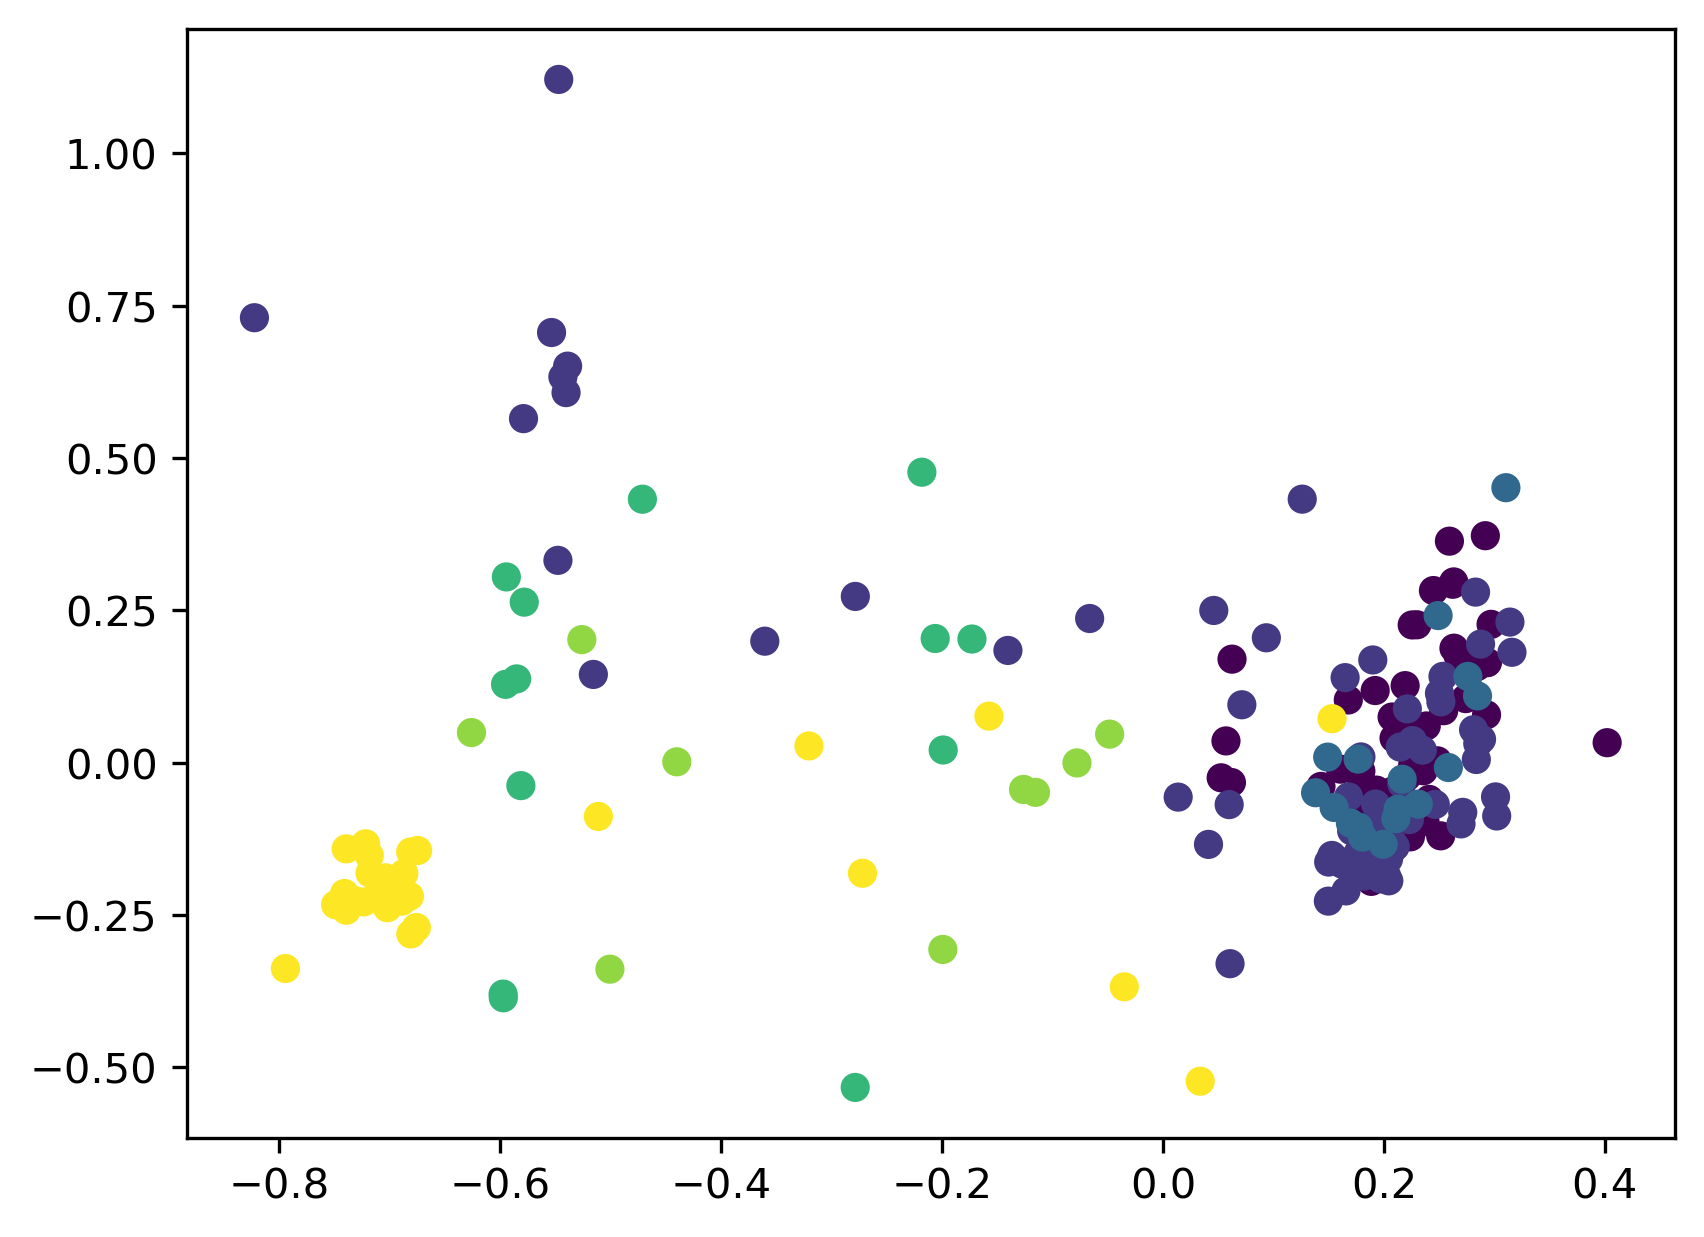

In [10]:
import matplotlib.pyplot as plt  
# 시각화를 위한 matplotlib의 pyplot 모듈을 불러오는 명령문
# pyplot은 MATLAB 스타일의 인터페이스를 제공하며, 다양한 형태의 시각화를 직접 구성할 수 있는 저수준 함수 제공

plt.scatter(x=df_concat['C1'], y=df_concat['C2'], c=df_concat['Type'])  
# matplotlib의 scatter() 함수를 이용해 산점도를 생성하는 명령문
# x축 좌표에는 주성분 C1, y축 좌표에는 주성분 C2를 설정함
# c=df_concat['Type']은 점의 색상을 'Type' 클래스 값에 따라 다르게 지정함 (정수형 또는 범주형 값이 자동으로 색상 매핑됨)
# 결과적으로 각 데이터 포인트가 주성분 공간상에서 어느 클래스(Type)에 속하는지를 색상으로 시각화함
# seaborn과 달리 범례(legend)와 스타일 지정이 자동으로 추가되지 않기 때문에 별도 설정이 필요함